# Session 5 — Baseline ML Pipeline
## Customer Value Classifier: `High-Value / Low-Value`

**Team:** GraphMinds — Riya · Atharva · Farhan · Sacharith · Shubhendu  
**Course:** Big Data and Business Intelligence Capstone

---

### Business Question
> *Is this customer a High-Value or Low-Value customer based on their 2020 spending?*

**Decision maker:** Store Manager at H&M  
**Model output:** `High-Value` or `Low-Value` per customer  
**Target rule:** Customers who spent above the median in 2020 = High-Value. At or below = Low-Value.

---

### S5 Features — Degree Counts Only
| Feature | Source | Type |
|---|---|---|
| `purchase_degree` | Cypher COUNT all-time | Numerical |
| `purchase_degree_2020` | Cypher COUNT 2020 only | Numerical |
| `sections_visited` | Cypher COUNT DISTINCT sections | Numerical |
| `age` | Neo4j node property | Numerical |
| `ageBand` | Neo4j node property | Categorical |
| `memberStatus` | Neo4j node property | Categorical |

> **NO PageRank. NO Louvain.**  
> Those are S6 deliverables — joined onto this matrix via `node_id` = `customerId`.

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from neo4j import GraphDatabase
import joblib, os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful ✓')

All imports successful ✓


## Cell 2 — Neo4j Connection

In [2]:
NEO4J_URI      = 'neo4j://127.0.0.1:7687'
NEO4J_USER     = 'neo4j'
NEO4J_PASSWORD = 'instance1'
MODELS_DIR     = Path('C:/Jupyter/abc/models')

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def run(query, params={}):
    with driver.session() as session:
        return session.run(query, params).data()

print('Connected to Neo4j ✓')

Connected to Neo4j ✓


## Cell 3 — Pull Degree Features via Cypher

`OPTIONAL MATCH` keeps customers with zero purchases — they are valid Low-Value rows.  
S5 scope: degree counts only. NO PageRank, NO Louvain.

In [3]:
degree_query = """
MATCH (c:Customer)

OPTIONAL MATCH (c)-[p:PURCHASED]->()
WITH c, COUNT(p) AS purchase_degree

OPTIONAL MATCH (c)-[p2020:PURCHASED]->()
WHERE p2020.yearMonth STARTS WITH '2020'
WITH c, purchase_degree, COUNT(p2020) AS purchase_degree_2020

OPTIONAL MATCH (c)-[ps:PURCHASED]->(a:Article)
WHERE ps.yearMonth STARTS WITH '2020'
WITH c, purchase_degree, purchase_degree_2020,
     COUNT(DISTINCT a.storeSection) AS sections_visited

RETURN
    c.customerId   AS node_id,
    c.age          AS age,
    c.ageBand      AS ageBand,
    c.memberStatus AS memberStatus,
    purchase_degree,
    purchase_degree_2020,
    sections_visited
"""

with driver.session() as session:
    result = session.run(degree_query).data()

df = pd.DataFrame(result)
print(f'Customers loaded: {len(df):,}')
df.head()

Customers loaded: 1,371,980


,node_id,age,ageBand,memberStatus,purchase_degree,purchase_degree_2020,sections_visited
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,49,40s,ACTIVE,9,1,1
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,25,20s,ACTIVE,5,2,2
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,24,20s,ACTIVE,0,0,0
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,54,50s,ACTIVE,0,0,0
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,52,50s,ACTIVE,2,0,0


## Cell 4 — Pull 2020 Spend per Customer

In [4]:
spend_query = """
MATCH (c:Customer)-[r:PURCHASED]->()
WHERE r.yearMonth STARTS WITH '2020'
RETURN
    c.customerId AS node_id,
    SUM(toFloat(r.price)) AS total_spend_2020
"""

with driver.session() as session:
    spend_result = session.run(spend_query).data()

df_spend = pd.DataFrame(spend_result)
print(f'Customers with 2020 spend: {len(df_spend):,}')
df_spend.head()

Customers with 2020 spend: 422,621


,node_id,total_spend_2020
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0508
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.0491
2,00007e8d4e54114b5b2a9b51586325a8d0fa74ea23ef77...,0.0534
3,00009c2aeae8761f738e4f937d9be6b49861a66339c2b1...,0.0675
4,0000b2f1829e23b24feec422ef13df3ccedaedc85368e6...,0.3221


## Cell 5 — Build Target Label

**Rule:** Above median 2020 spend = `High-Value`. At or below = `Low-Value`.

Median 2020 spend (active customers): £0.0997

Class distribution:
customer_value
Low-Value     1160670
High-Value     211310
Name: count, dtype: int64


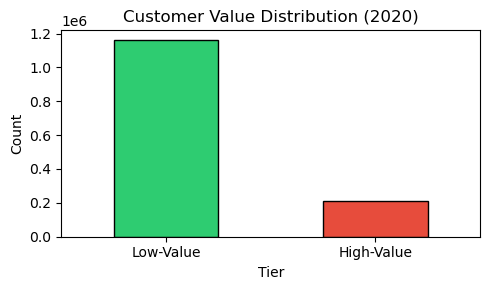

In [5]:
df = df.merge(df_spend, on='node_id', how='left')
df['total_spend_2020'] = df['total_spend_2020'].fillna(0.0)

median_spend = df[df['total_spend_2020'] > 0]['total_spend_2020'].median()
print(f'Median 2020 spend (active customers): £{median_spend:.4f}')

df['customer_value'] = df['total_spend_2020'].apply(
    lambda x: 'High-Value' if x > median_spend else 'Low-Value'
)

print('\nClass distribution:')
print(df['customer_value'].value_counts())

plt.figure(figsize=(5, 3))
df['customer_value'].value_counts().plot(
    kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black'
)
plt.title('Customer Value Distribution (2020)')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cell 6 — Clean Features

In [6]:
df['age']          = pd.to_numeric(df['age'], errors='coerce').fillna(df['age'].median())
df['ageBand']      = df['ageBand'].fillna('Unknown')
df['memberStatus'] = df['memberStatus'].fillna('Unknown')

for col in ['purchase_degree', 'purchase_degree_2020', 'sections_visited']:
    df[col] = df[col].fillna(0).astype(int)

print(f'Dataset ready: {len(df):,} customers')
print('Any nulls:')
print(df[['purchase_degree', 'purchase_degree_2020',
          'sections_visited', 'age', 'ageBand', 'memberStatus']].isnull().sum())

Dataset ready: 1,371,980 customers
Any nulls:
purchase_degree         0
purchase_degree_2020    0
sections_visited        0
age                     0
ageBand                 0
memberStatus            0
dtype: int64


## Cell 7 — Define Features & Split First

> `node_id` = `customerId` as index — never a model input.  
> S6 merges `pagerank` + `community` onto this same index.

In [7]:
numerical_features   = ['purchase_degree', 'purchase_degree_2020', 'sections_visited', 'age']
categorical_features = ['ageBand', 'memberStatus']

X = df[numerical_features + categorical_features].copy()
y = df['customer_value']
X.index = df['node_id']  # customerId as index — S6 merge key

# SPLIT FIRST — mandatory before any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Features: {len(numerical_features)} numerical + {len(categorical_features)} categorical')

Train: 1,097,584  |  Test: 274,396
Features: 4 numerical + 2 categorical


## Cell 8 — Build Pipeline & Train

> Scaler lives INSIDE the Pipeline — leakage impossible.

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
                         class_weight='balanced',
                         random_state=42,
                         n_jobs=1))        # RF uses 1 core — GridSearch handles parallelism
])

param_grid = {
    'classifier__n_estimators':      [100, 200],
    'classifier__max_depth':         [5, 10],    # removed None
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=2,          # only 2 folds run in parallel — safe for local RAM
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)
pipeline = grid_search.best_estimator_

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV f1_weighted: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV f1_weighted: 0.9440


## Cell 9 — S5 Baseline Evaluation

> **This is the BEFORE number. S6 must beat this F1.**

=== S5 BASELINE — Customer Value Classifier ===
Features: degree counts only (NO PageRank, NO Louvain)

              precision    recall  f1-score   support

  High-Value       0.73      0.97      0.84     42262
   Low-Value       0.99      0.94      0.96    232134

    accuracy                           0.94    274396
   macro avg       0.86      0.95      0.90    274396
weighted avg       0.95      0.94      0.94    274396

=== S5 ROBUSTNESS CHECK (train set CV) ===
F1 per fold:  [np.float64(0.9448), np.float64(0.9431), np.float64(0.9441), np.float64(0.944), np.float64(0.9452)]
Mean F1:      0.9443
Std (stability): 0.0007


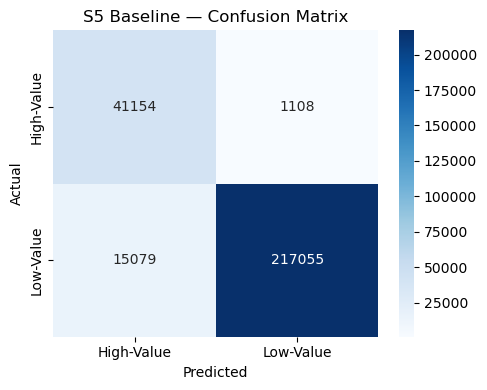

In [9]:
y_pred = pipeline.predict(X_test)

print('=== S5 BASELINE — Customer Value Classifier ===')
print('Features: degree counts only (NO PageRank, NO Louvain)')
print()

# Bug fix: labels= pins order so target_names maps correctly
print(classification_report(
    y_test, y_pred,
    labels=['High-Value', 'Low-Value'],
    target_names=['High-Value', 'Low-Value']
))

# Cross-validation on train set only — never touch X_test here
cv_scores = cross_val_score(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)
print('=== S5 ROBUSTNESS CHECK (train set CV) ===')
print(f'F1 per fold:  {[round(s, 4) for s in cv_scores]}')
print(f'Mean F1:      {cv_scores.mean():.4f}')
print(f'Std (stability): {cv_scores.std():.4f}')

cm = confusion_matrix(y_test, y_pred, labels=['High-Value', 'Low-Value'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High-Value', 'Low-Value'],
            yticklabels=['High-Value', 'Low-Value'])
plt.title('S5 Baseline — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Cell 10 — Feature Importance

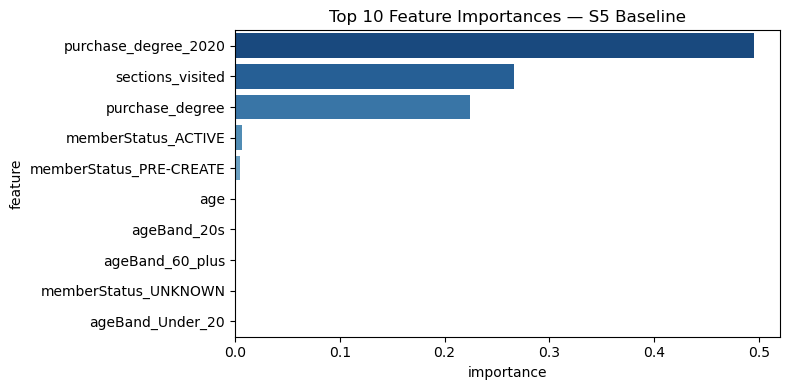

                feature  importance
   purchase_degree_2020    0.495360
       sections_visited    0.266291
        purchase_degree    0.224052
    memberStatus_ACTIVE    0.007053
memberStatus_PRE-CREATE    0.005091
                    age    0.001212
            ageBand_20s    0.000264
        ageBand_60_plus    0.000178
   memberStatus_UNKNOWN    0.000166
       ageBand_Under_20    0.000146


In [10]:
cat_feature_names = list(
    pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
all_feature_names = numerical_features + cat_feature_names
importances       = pipeline.named_steps['classifier'].feature_importances_

feat_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_df, x='importance', y='feature',hue='feature', palette='Blues_r', legend=False)
plt.title('Top 10 Feature Importances — S5 Baseline')
plt.tight_layout()
plt.show()
print(feat_df.to_string(index=False))

## Cell 11 — Save Model & S5 Matrix

In [11]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline, MODELS_DIR / 'customer_value_classifier.pkl')
print('Model saved → customer_value_classifier.pkl')

s5_matrix = X_train.copy()
s5_matrix['customer_value'] = y_train          # bug fix: no .values — keeps index aligned
s5_matrix.index.name = 'node_id'
s5_matrix.to_parquet(MODELS_DIR / 's5_matrix.parquet')
print('S5 matrix saved → s5_matrix.parquet')
print(f'Shape: {s5_matrix.shape}')
print('Index name: node_id (customerId) — S6 merges pagerank + community here')

Model saved → customer_value_classifier.pkl
S5 matrix saved → s5_matrix.parquet
Shape: (1097584, 7)
Index name: node_id (customerId) — S6 merges pagerank + community here


---
## S5 Baseline Summary

| Item | Value |
|---|---|
| **Target** | High-Value vs Low-Value |
| **Target rule** | Above median 2020 spend = High-Value |
| **node_id** | customerId — same key S6 uses for merge |
| **Features** | Degree counts only — NO PageRank / Louvain |
| **Model** | RandomForestClassifier (n=200, balanced) |
| **Leakage** | Prevented — scaler inside Pipeline, split first |
| **S6 task** | Run PageRank + Louvain on Customer nodes → merge → re-train |